# 07 — Collaborative Filtering (CF) para Instacart

Este notebook implementa tres enfoques de **Collaborative Filtering** para generar recomendaciones personalizadas de productos:

1. **Baseline — Popularidad**: recomienda los productos más populares no comprados por el usuario.
2. **Item-Item Cosine Similarity**: similitud entre productos basada en patrones de co-compra.
3. **TruncatedSVD** (Matrix Factorization): descomposición SVD de la matriz user-item.
4. **ALS** (Alternating Least Squares, librería `implicit`): factorización matricial optimizada para datos implícitos.

**Objetivo:** superar el baseline de popularidad (F1@10 = 0.046) con al menos uno de los modelos CF.

## Sección 1: Setup e Imports

Importamos todas las bibliotecas necesarias y definimos las constantes globales:

- **implicit.als.AlternatingLeastSquares**: modelo ALS optimizado para feedback implícito (conteos de compras).
- **TruncatedSVD**: descomposición de valor singular truncada para reducción de dimensionalidad.
- **scipy.sparse**: matrices sparse para manejar eficientemente la matriz user-item (muy rala).
- **MIN_PRODUCT_PURCHASES = 50**: filtramos productos con pocas compras para reducir ruido.
- **MIN_USER_ORDERS = 5**: filtramos usuarios con poco historial.

In [2]:
import os
import time
import warnings
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
from scipy import sparse
from scipy.sparse import csr_matrix, save_npz, load_npz
from sklearn.decomposition import TruncatedSVD
from sklearn.metrics.pairwise import cosine_similarity
from sklearn.preprocessing import normalize
from implicit.als import AlternatingLeastSquares
import joblib

warnings.filterwarnings('ignore')
%matplotlib inline
sns.set_style('whitegrid')
plt.rcParams['figure.figsize'] = (12, 6)

RAW_DIR = os.path.join('..', 'data', 'raw', 'instacart')
PROCESSED_DIR = os.path.join('..', 'data', 'processed')
MODELS_DIR = os.path.join('..', 'models')
RANDOM_STATE = 42
MIN_PRODUCT_PURCHASES = 50
MIN_USER_ORDERS = 5

os.makedirs(PROCESSED_DIR, exist_ok=True)
os.makedirs(MODELS_DIR, exist_ok=True)

print('Setup completo.')
print(f'RAW_DIR      : {os.path.abspath(RAW_DIR)}')
print(f'PROCESSED_DIR: {os.path.abspath(PROCESSED_DIR)}')
print(f'MODELS_DIR   : {os.path.abspath(MODELS_DIR)}')

Setup completo.
RAW_DIR      : c:\henry\ProyectoFinal-DataScience-Henry\data\raw\instacart
PROCESSED_DIR: c:\henry\ProyectoFinal-DataScience-Henry\data\processed
MODELS_DIR   : c:\henry\ProyectoFinal-DataScience-Henry\models


## Sección 2: Carga de Datos

Cargamos los archivos raw de Instacart usando únicamente las columnas necesarias para minimizar el uso de memoria:

- **orders.csv**: separamos órdenes `prior` (historial de compras) de `train` (último carrito = ground truth de evaluación).
- **order_products__prior.csv**: ítems de cada orden histórica.
- **order_products__train.csv**: ítems del último carrito (set de evaluación de la competencia Kaggle).
- **products.csv**: nombres de productos para interpretación.

El resultado final es:
- `df_prior`: todas las compras históricas con `[user_id, product_id]`.
- `df_test`: el último carrito de cada usuario, usado como **ground truth** para evaluar las recomendaciones.

In [3]:
# ── Cargar orders ─────────────────────────────────────────────────────────────
orders = pd.read_csv(
    os.path.join(RAW_DIR, 'orders.csv'),
    usecols=['order_id', 'user_id', 'eval_set']
)

orders_prior = orders[orders['eval_set'] == 'prior'].copy()
orders_train = orders[orders['eval_set'] == 'train'].copy()
print(f'Órdenes prior : {len(orders_prior):>10,}')
print(f'Órdenes train : {len(orders_train):>10,}')

# ── Cargar order_products ─────────────────────────────────────────────────────
order_products_prior = pd.read_csv(
    os.path.join(RAW_DIR, 'order_products__prior.csv'),
    usecols=['order_id', 'product_id']
)
order_products_train = pd.read_csv(
    os.path.join(RAW_DIR, 'order_products__train.csv'),
    usecols=['order_id', 'product_id']
)

# ── Cargar products ───────────────────────────────────────────────────────────
products = pd.read_csv(
    os.path.join(RAW_DIR, 'products.csv'),
    usecols=['product_id', 'product_name']
)

# ── Merge: obtener user_id para cada ítem ─────────────────────────────────────
df_prior = order_products_prior.merge(
    orders_prior[['order_id', 'user_id']], on='order_id', how='inner'
)[['user_id', 'product_id']]

df_test = order_products_train.merge(
    orders_train[['order_id', 'user_id']], on='order_id', how='inner'
)[['user_id', 'product_id']]

print(f'\ndf_prior shape : {df_prior.shape}')
print(f'df_test shape  : {df_test.shape}')
print(f'Usuarios en prior : {df_prior["user_id"].nunique():>10,}')
print(f'Usuarios en test  : {df_test["user_id"].nunique():>10,}')
print(f'Productos en prior: {df_prior["product_id"].nunique():>10,}')
df_prior.head()

Órdenes prior :  3,214,874
Órdenes train :    131,209

df_prior shape : (32434489, 2)
df_test shape  : (1384617, 2)
Usuarios en prior :    206,209
Usuarios en test  :    131,209
Productos en prior:     49,677


,user_id,product_id
0,202279,33120
1,202279,28985
2,202279,9327
3,202279,45918
4,202279,30035


## Sección 3: Filtrado y Construcción de Matrices Sparse

Para hacer el problema manejable en memoria y tiempo, aplicamos dos filtros:

1. **Productos frecuentes** (≥ `MIN_PRODUCT_PURCHASES` compras): eliminamos productos muy raros que aportan poco señal.
2. **Usuarios activos** (≥ `MIN_USER_ORDERS` órdenes distintas): eliminamos usuarios con historial muy escaso.

Se construyen **dos matrices** con distinto preprocesamiento de los valores de celda:

- **`user_item_sparse` (log1p):** `log1p(count)` suaviza outliers y se usa para Item-Item Cosine (donde la similitud no depende del esquema de weighting global).
- **`user_item_bm25` (BM25):** weighting BM25 sobre los mismos conteos — es el estándar de la literatura para ALS con feedback implícito. BM25 ajusta el peso de cada (usuario, ítem) por la popularidad global del ítem (IDF) y la longitud del historial del usuario (normalización TF), lo que reduce el sesgo hacia ítems ultra-populares.

La sparsity esperada es alta (>99.7%), lo que justifica el uso de matrices sparse (`scipy.csr_matrix`) en lugar de dense arrays.

In [4]:
# Filtrar productos con >= MIN_PRODUCT_PURCHASES compras
product_counts = df_prior['product_id'].value_counts()
valid_products = product_counts[product_counts >= MIN_PRODUCT_PURCHASES].index
print(f"Productos con >={MIN_PRODUCT_PURCHASES} compras: {len(valid_products):,} de {df_prior['product_id'].nunique():,}")

# Filtrar usuarios con >= MIN_USER_ORDERS orders
user_order_counts = orders_prior.groupby('user_id')['order_id'].nunique()
valid_users = user_order_counts[user_order_counts >= MIN_USER_ORDERS].index
print(f"Usuarios con >={MIN_USER_ORDERS} orders: {len(valid_users):,} de {orders_prior['user_id'].nunique():,}")

# Filtrar df_prior
df_filtered = df_prior[df_prior['product_id'].isin(valid_products) & df_prior['user_id'].isin(valid_users)]

# Agregar: conteo de compras por (user, product)
user_product_counts = df_filtered.groupby(['user_id', 'product_id']).size().reset_index(name='count')

# Crear mappings
user_ids = user_product_counts['user_id'].unique()
product_ids = user_product_counts['product_id'].unique()
user_to_idx = {uid: i for i, uid in enumerate(user_ids)}
product_to_idx = {pid: i for i, pid in enumerate(product_ids)}
idx_to_user = {i: uid for uid, i in user_to_idx.items()}
idx_to_product = {i: pid for pid, i in product_to_idx.items()}

rows = user_product_counts['user_id'].map(user_to_idx).values
cols = user_product_counts['product_id'].map(product_to_idx).values
raw_counts = user_product_counts['count'].values.astype(np.float32)

# Matriz de conteos crudos (base para BM25)
user_item_raw = csr_matrix((raw_counts, (rows, cols)),
                            shape=(len(user_ids), len(product_ids)))

# Matriz log1p (para Item-Item Cosine)
user_item_sparse = csr_matrix((np.log1p(raw_counts), (rows, cols)),
                               shape=(len(user_ids), len(product_ids)))

print(f"\nMatriz user-item: {user_item_sparse.shape}")
print(f"Entradas no-cero: {user_item_sparse.nnz:,}")
print(f"Sparsity: {1 - user_item_sparse.nnz / (user_item_sparse.shape[0] * user_item_sparse.shape[1]):.4%}")
print(f"user_item_raw (conteos crudos) y user_item_sparse (log1p) creadas.")

Productos con >=50 compras: 26,686 de 49,677
Usuarios con >=5 orders: 162,633 de 206,209

Matriz user-item: (162632, 26686)
Entradas no-cero: 11,931,900
Sparsity: 99.7251%
user_item_raw (conteos crudos) y user_item_sparse (log1p) creadas.


### 3b. Construcción de la Matriz BM25 (para ALS)

Para ALS con feedback implícito, el estándar de la literatura es **BM25 weighting** en lugar de `log1p`. BM25 aplica dos ajustes:

1. **Componente TF** (saturación de frecuencia): `tf_bm25 = count * (K1+1) / (count + K1 * (1 - B + B * len_user / avg_len))`. Esto satura el peso de ítems muy repetidos y normaliza por la longitud del historial del usuario (`B=0.8`, sensibilidad a la longitud).
2. **Componente IDF**: `idf = log((n_users + 1) / (df_item + 1))`. Penaliza ítems muy populares (comprados por muchos usuarios) que tienen menos poder discriminativo.

El resultado es una matriz sparse del mismo shape que `user_item_sparse` pero con valores BM25 en lugar de `log1p`. Se conserva `user_item_sparse` (log1p) para Item-Item Cosine, que no se beneficia del weighting global de la misma manera.

In [5]:
def build_bm25_matrix(X, K1=100, B=0.8):
    """
    Aplica BM25 weighting a una matriz user×item CSR de conteos crudos.
    K1: parámetro de saturación del TF (100 = muy suave, equivale casi a IDF puro).
    B:  sensibilidad a la longitud del historial del usuario (0=sin normalizar, 1=full).
    """
    X = X.astype(np.float32)
    n_users = X.shape[0]
    doc_lengths = np.asarray(X.sum(axis=1)).flatten()
    avg_dl = doc_lengths.mean()

    cx = X.tocoo()
    tf = cx.data.copy()
    dl = doc_lengths[cx.row]
    bm25_tf = (tf * (K1 + 1)) / (tf + K1 * (1 - B + B * dl / avg_dl))

    df_per_item = np.asarray((X > 0).sum(axis=0)).flatten()
    idf = np.log((n_users + 1) / (df_per_item + 1)).astype(np.float32)

    bm25_data = bm25_tf * idf[cx.col]
    return csr_matrix((bm25_data, (cx.row, cx.col)), shape=X.shape)

# Aplicar BM25 a conteos crudos (no log1p)
user_item_bm25 = build_bm25_matrix(user_item_raw)
print(f"user_item_bm25 : shape={user_item_bm25.shape}, nnz={user_item_bm25.nnz:,}")
print(f"Valores BM25   : min={user_item_bm25.data.min():.3f}  max={user_item_bm25.data.max():.3f}  media={user_item_bm25.data.mean():.3f}")
print(f"user_item_sparse (log1p) conservada para Item-Item Cosine.")

user_item_bm25 : shape=(162632, 26686), nnz=11,931,900
Valores BM25   : min=0.086  max=398.400  media=8.941
user_item_sparse (log1p) conservada para Item-Item Cosine.


## Sección 4: Preparar Ground Truth

Preparamos el conjunto de evaluación:

- Solo evaluamos usuarios que existen en nuestra matriz (filtraron con los criterios de la Sección 3).
- Solo consideramos productos que existen en nuestra matriz (los que tienen ≥ `MIN_PRODUCT_PURCHASES` compras).
- El ground truth es el **último carrito** de cada usuario (`eval_set == 'train'`), representado como un `set` de `product_id`s.

Esto garantiza que las métricas de precisión y recall sean calculables (el denominador nunca es 0).

In [6]:
# Filtrar test set a usuarios y productos que existen en nuestra matriz
df_test_filtered = df_test[
    df_test['user_id'].isin(user_to_idx) &
    df_test['product_id'].isin(product_to_idx)
]

# Ground truth como dict: user_id → set(product_ids)
ground_truth = df_test_filtered.groupby('user_id')['product_id'].apply(set).to_dict()
print(f"Usuarios evaluables: {len(ground_truth):,}")
print(f"Tamaño medio del carrito test: {np.mean([len(v) for v in ground_truth.values()]):.1f} productos")
print(f"Tamaño mediano del carrito test: {np.median([len(v) for v in ground_truth.values()]):.1f} productos")

Usuarios evaluables: 103,325
Tamaño medio del carrito test: 10.6 productos
Tamaño mediano del carrito test: 9.0 productos


## Sección 5: Funciones de Evaluación

Definimos la función `evaluate_recommendations` que calcula métricas estándar de sistemas de recomendación:

- **Precision@K**: de los K productos recomendados, ¿qué fracción está en el carrito real?
- **Recall@K**: de todos los productos del carrito real, ¿qué fracción fue recomendada en el top-K?
- **F1@K**: media harmónica de Precision y Recall.
- **NDCG@K** *(nuevo)*: Normalized Discounted Cumulative Gain — penaliza encontrar ítems relevantes en posiciones bajas de la lista. Es más informativa que F1 porque captura la *calidad del ranking*, no sólo si los ítems correctos están entre los K recomendados. NDCG@K = 1 si todos los ítems relevantes aparecen en las primeras posiciones.

Evaluamos con K ∈ {5, 10, 20}.

In [7]:
def evaluate_recommendations(recs, truth, k_values=[5, 10, 20]):
    """
    recs:  dict {user_id: list of product_ids (ordered by score, descending)}
    truth: dict {user_id: set of product_ids}
    Retorna: (dict con métricas por k, número de usuarios comunes evaluados)
    """
    results = {}
    common_users = set(recs.keys()) & set(truth.keys())

    for k in k_values:
        precisions, recalls, ndcgs = [], [], []
        for uid in common_users:
            rec_list = recs[uid][:k]
            rec_set  = set(rec_list)
            actual   = truth[uid]
            if len(actual) == 0:
                continue
            hits = len(rec_set & actual)
            precisions.append(hits / k)
            recalls.append(hits / len(actual))

            # NDCG@K — penaliza hits en posiciones bajas
            dcg  = sum(
                (1 if rec_list[i] in actual else 0) / np.log2(i + 2)
                for i in range(len(rec_list))
            )
            n_rel = min(len(actual), k)
            idcg  = sum(1.0 / np.log2(i + 2) for i in range(n_rel))
            ndcgs.append(dcg / idcg if idcg > 0 else 0.0)

        avg_p  = np.mean(precisions)
        avg_r  = np.mean(recalls)
        avg_f1 = 2 * avg_p * avg_r / (avg_p + avg_r) if (avg_p + avg_r) > 0 else 0
        results[k] = {
            'precision': avg_p,
            'recall':    avg_r,
            'f1':        avg_f1,
            'ndcg':      np.mean(ndcgs),
        }

    return results, len(common_users)

print("Función evaluate_recommendations definida (incluye NDCG@K).")

Función evaluate_recommendations definida (incluye NDCG@K).


## Sección 6: Baseline — Popularidad

El baseline más simple es recomendar los **productos más populares** (por número de usuarios que los compraron) que el usuario aún no haya comprado.

Este baseline es difícil de superar para la métrica de **Precisión**, porque los productos populares son muy probables en cualquier carrito. Sin embargo, no es personalizado — todos los usuarios reciben las mismas recomendaciones.

El baseline externo dado es: Precision@5=0.067, Recall@5=0.033, F1@5=0.039, F1@10=0.046.

In [8]:
# Top-N productos más comprados (por número de usuarios que los compraron)
product_popularity = df_filtered.groupby('product_id')['user_id'].nunique().sort_values(ascending=False)
popular_products = product_popularity.index.tolist()

# Historial de compras por usuario (para excluir ya comprados)
user_purchased = df_filtered.groupby('user_id')['product_id'].apply(set).to_dict()

t0 = time.time()
recs_popularity = {}
for uid in ground_truth:
    purchased = user_purchased.get(uid, set())
    recs_popularity[uid] = [p for p in popular_products if p not in purchased][:20]
time_pop = time.time() - t0

metrics_pop, n_users_pop = evaluate_recommendations(recs_popularity, ground_truth)
print(f"Baseline Popularidad ({n_users_pop:,} usuarios, {time_pop:.1f}s):")
for k, m in metrics_pop.items():
    print(f"  @{k}: P={m['precision']:.4f}, R={m['recall']:.4f}, F1={m['f1']:.4f}")

Baseline Popularidad (103,325 usuarios, 106.4s):
  @5: P=0.0187, R=0.0088, F1=0.0120
  @10: P=0.0152, R=0.0142, F1=0.0147
  @20: P=0.0123, R=0.0221, F1=0.0158


## Sección 7: Item-Item Cosine Similarity

### 7a. Computar Matriz de Similitud Sparse (en Batches)

La similitud coseno entre items se calcula como el producto punto de los vectores item normalizados (norma L2).

**Problema de memoria**: calcular la similitud entre ~26k productos produciría una matriz densa de 26k × 26k ≈ 5.7 GB. En cambio:

1. Transponemos para obtener la matriz **item × user** (productos como filas).
2. Normalizamos cada fila (norma L2) para que el producto punto = similitud coseno.
3. Calculamos la similitud en **batches de 1000 productos** contra todos los demás.
4. Para cada producto, mantenemos solo los **top-50 vecinos más similares** (similitud positiva).
5. Construimos una matriz sparse final con estos valores.

Este approach usa solo ~100 MB en vez de 5.7 GB.

In [9]:
# Transponer: item_user = user_item.T (products × users)
item_user = user_item_sparse.T.tocsr()

# Normalizar por filas (L2) para que dot product = cosine similarity
item_user_norm = normalize(item_user, norm='l2', axis=1)

n_items = item_user_norm.shape[0]
BATCH_SIZE = 1000
TOP_K_SIMILAR = 50

print(f"Calculando similitud item-item en batches de {BATCH_SIZE}...")
print(f"Manteniendo top-{TOP_K_SIMILAR} vecinos por item")
print(f"Total items: {n_items:,}, batches: {(n_items + BATCH_SIZE - 1) // BATCH_SIZE}")

# Almacenar en listas para construir sparse después
sim_rows, sim_cols, sim_vals = [], [], []

t0 = time.time()
for start in range(0, n_items, BATCH_SIZE):
    end = min(start + BATCH_SIZE, n_items)
    # Similitud de este batch contra todos los items
    batch_sim = item_user_norm[start:end] @ item_user_norm.T  # sparse result
    batch_sim = batch_sim.toarray() if sparse.issparse(batch_sim) else batch_sim

    # Para cada item en el batch, mantener solo top-K (excluyendo self)
    for local_i in range(batch_sim.shape[0]):
        global_i = start + local_i
        sims = batch_sim[local_i].copy()
        sims[global_i] = -1  # excluir self-similarity
        top_k_idx = np.argpartition(sims, -TOP_K_SIMILAR)[-TOP_K_SIMILAR:]
        top_k_idx = top_k_idx[sims[top_k_idx] > 0]  # solo positivos

        sim_rows.extend([global_i] * len(top_k_idx))
        sim_cols.extend(top_k_idx.tolist())
        sim_vals.extend(sims[top_k_idx].tolist())

    if (start // BATCH_SIZE) % 5 == 0:
        elapsed = time.time() - t0
        pct = 100 * end / n_items
        print(f"  Batch {start//BATCH_SIZE + 1}/{(n_items + BATCH_SIZE - 1)//BATCH_SIZE} "
              f"({pct:.1f}% | {elapsed:.0f}s)")

item_similarity = csr_matrix((sim_vals, (sim_rows, sim_cols)), shape=(n_items, n_items))
time_item_sim = time.time() - t0
print(f"\nSimilitud item-item completada en {time_item_sim:.0f}s")
print(f"Entries en la matriz de similitud: {item_similarity.nnz:,}")

Calculando similitud item-item en batches de 1000...
Manteniendo top-50 vecinos por item
Total items: 26,686, batches: 27
  Batch 1/27 (3.7% | 2s)
  Batch 6/27 (22.5% | 8s)
  Batch 11/27 (41.2% | 12s)
  Batch 16/27 (60.0% | 16s)
  Batch 21/27 (78.7% | 20s)
  Batch 26/27 (97.4% | 23s)

Similitud item-item completada en 24s
Entries en la matriz de similitud: 1,334,300


### 7b. Generar Recomendaciones Item-Item (todos los usuarios test)

Para generar recomendaciones a un usuario calculamos el **score de cada producto** como la suma ponderada de similitudes con los productos que el usuario ya compró:

`scores = user_vector @ item_similarity`

donde `user_vector` es la fila del usuario en la matriz user-item.

En lugar de evaluar sobre una submuestra (como en versiones anteriores), ahora evaluamos sobre **todos los usuarios test** (~103k) para una comparación justa con ALS, SVD y Popularidad. Para mantener tiempos razonables:
- Procesamos los usuarios en **batches de 5 000** — cada batch hace una multiplicación de matrices sparse (5k × 26k) @ (26k × 26k sparse), lo que vectoriza la mayor parte del trabajo.
- Usamos `np.argpartition` en lugar de `np.argsort` para obtener el top-20 en O(n) en vez de O(n log n).

In [10]:
EVAL_BATCH = 5_000
test_uids  = list(ground_truth.keys())
recs_itemitem = {}

n_batches = (len(test_uids) + EVAL_BATCH - 1) // EVAL_BATCH
t0 = time.time()
for batch_num, batch_start in enumerate(range(0, len(test_uids), EVAL_BATCH)):
    batch_uids = test_uids[batch_start : batch_start + EVAL_BATCH]
    batch_idx  = [user_to_idx[uid] for uid in batch_uids]
    user_slice = user_item_sparse[batch_idx]          # sparse (B × n_items)
    batch_scores = (user_slice @ item_similarity)     # sparse or dense (B × n_items)
    if sparse.issparse(batch_scores):
        batch_scores = batch_scores.toarray()
    for i, uid in enumerate(batch_uids):
        scores = batch_scores[i].copy()
        scores[user_item_sparse[user_to_idx[uid]].nonzero()[1]] = -np.inf
        top_idx = np.argpartition(scores, -20)[-20:]
        top_idx = top_idx[np.argsort(scores[top_idx])[::-1]]
        recs_itemitem[uid] = [idx_to_product[j] for j in top_idx]
    if (batch_num + 1) % 5 == 0 or (batch_num + 1) == n_batches:
        elapsed = time.time() - t0
        print(f"  Batch {batch_num+1}/{n_batches} — {len(recs_itemitem):,} usuarios ({elapsed:.0f}s)")

time_itemitem_rec = time.time() - t0
print(f"\nTotal usuarios con recomendaciones Item-Item: {len(recs_itemitem):,}")

metrics_ii, n_users_ii = evaluate_recommendations(recs_itemitem, ground_truth)
print(f"\nEvaluación Item-Item Cosine ({n_users_ii:,} usuarios, sim={time_item_sim:.0f}s + rec={time_itemitem_rec:.0f}s):")
for k, m in metrics_ii.items():
    print(f"  @{k:2d}: P={m['precision']:.4f}  R={m['recall']:.4f}  F1={m['f1']:.4f}  NDCG={m['ndcg']:.4f}")

  Batch 5/21 — 25,000 usuarios (15s)
  Batch 10/21 — 50,000 usuarios (30s)
  Batch 15/21 — 75,000 usuarios (45s)
  Batch 20/21 — 100,000 usuarios (60s)
  Batch 21/21 — 103,325 usuarios (62s)

Total usuarios con recomendaciones Item-Item: 103,325

Evaluación Item-Item Cosine (103,325 usuarios, sim=24s + rec=62s):
  @ 5: P=0.0219  R=0.0107  F1=0.0144  NDCG=0.0246
  @10: P=0.0180  R=0.0173  F1=0.0176  NDCG=0.0231
  @20: P=0.0142  R=0.0269  F1=0.0186  NDCG=0.0248


## Sección 8: TruncatedSVD — Barrido de Factores [20, 50, 100]

**TruncatedSVD** descompone la matriz user-item (U × I) en:

`U ≈ user_factors (U × k) @ item_factors.T (k × I)`

donde `k` es el número de factores latentes (dimensiones reducidas).

Los factores latentes capturan **patrones de co-compra** entre usuarios y productos sin necesidad de calcular similitudes explícitas.

Para generar recomendaciones: `scores = user_factors[u] @ item_factors.T` — un producto punto que da el "interés estimado" del usuario en cada producto.

**Nota crítica de memoria**: para 131k usuarios no computamos `user_factors @ item_factors.T` completo (sería 131k × 26k = 3.4B floats ≈ 27 GB). En cambio procesamos en **batches de 5000 usuarios**.

In [11]:
svd_results = {}
best_svd_f1 = 0
best_svd_k = None
best_svd_model = None
best_svd_recs = None

for n_components in [20, 50, 100]:
    print(f"\n--- TruncatedSVD con {n_components} componentes ---")
    t0 = time.time()
    svd = TruncatedSVD(n_components=n_components, random_state=RANDOM_STATE)
    user_factors = svd.fit_transform(user_item_sparse)  # users × k
    item_factors = svd.components_.T  # products × k
    time_train = time.time() - t0
    print(f"  Varianza explicada: {svd.explained_variance_ratio_.sum():.4f}")
    print(f"  Tiempo entrenamiento: {time_train:.1f}s")

    # Generar recomendaciones para test users (en batches de 5000)
    t0 = time.time()
    recs_svd = {}
    BATCH = 5000
    test_uids = list(ground_truth.keys())

    for batch_start in range(0, len(test_uids), BATCH):
        batch_uids = test_uids[batch_start:batch_start + BATCH]
        batch_idx = [user_to_idx[uid] for uid in batch_uids]

        # Scores: user_factors[batch] @ item_factors.T → batch × n_products
        batch_scores = user_factors[batch_idx] @ item_factors.T

        for i, uid in enumerate(batch_uids):
            scores = batch_scores[i].copy()
            # Maskear ya comprados
            purchased_idx = user_item_sparse[user_to_idx[uid]].nonzero()[1]
            scores[purchased_idx] = -np.inf
            top_idx = np.argsort(scores)[-20:][::-1]
            recs_svd[uid] = [idx_to_product[j] for j in top_idx]

    time_rec = time.time() - t0

    metrics_svd, n_users_svd = evaluate_recommendations(recs_svd, ground_truth)
    svd_results[n_components] = {
        'metrics': metrics_svd,
        'time_train': time_train,
        'time_rec': time_rec,
        'n_users': n_users_svd
    }

    f1_10 = metrics_svd[10]['f1']
    if f1_10 > best_svd_f1:
        best_svd_f1 = f1_10
        best_svd_k = n_components
        best_svd_model = svd
        best_svd_recs = recs_svd

    print(f"  Recomendaciones generadas en {time_rec:.1f}s para {n_users_svd:,} usuarios")
    for k, m in metrics_svd.items():
        print(f"  @{k}: P={m['precision']:.4f}, R={m['recall']:.4f}, F1={m['f1']:.4f}")

print(f"\nMejor SVD: {best_svd_k} componentes (F1@10={best_svd_f1:.4f})")


--- TruncatedSVD con 20 componentes ---
  Varianza explicada: 0.1307
  Tiempo entrenamiento: 1.6s
  Recomendaciones generadas en 78.0s para 103,325 usuarios
  @5: P=0.0169, R=0.0082, F1=0.0111
  @10: P=0.0147, R=0.0140, F1=0.0143
  @20: P=0.0123, R=0.0233, F1=0.0161

--- TruncatedSVD con 50 componentes ---
  Varianza explicada: 0.1865
  Tiempo entrenamiento: 3.3s
  Recomendaciones generadas en 79.9s para 103,325 usuarios
  @5: P=0.0145, R=0.0072, F1=0.0096
  @10: P=0.0126, R=0.0122, F1=0.0124
  @20: P=0.0106, R=0.0206, F1=0.0140

--- TruncatedSVD con 100 componentes ---
  Varianza explicada: 0.2474
  Tiempo entrenamiento: 7.4s
  Recomendaciones generadas en 75.9s para 103,325 usuarios
  @5: P=0.0111, R=0.0058, F1=0.0076
  @10: P=0.0096, R=0.0099, F1=0.0097
  @20: P=0.0083, R=0.0168, F1=0.0112

Mejor SVD: 20 componentes (F1@10=0.0143)


## Sección 9: ALS (Alternating Least Squares) con BM25 Weighting

ALS factoriza la matriz usuario×ítem en dos matrices latentes (usuarios y productos) mediante mínimos cuadrados alternados, fijando una y optimizando la otra hasta convergencia.

**Mejoras en esta versión:**

- **BM25 como matriz de entrada** (en lugar de `log1p`): estándar de la literatura para ALS con feedback implícito. BM25 pondera cada interacción (usuario, ítem) considerando la popularidad global del ítem (IDF) y la longitud del historial del usuario (normalización TF), lo que reduce el sesgo hacia ítems ultra-populares como "Banana" o "Avocados".
- **`regularization=0.1`** (antes 0.01): la regularización anterior era demasiado baja para una matriz de 162k × 26k usuarios, lo que provocaba overfitting. Con L2 más fuerte, los vectores latentes generalizan mejor.
- **`iterations=30`** (antes 15): con la regularización mayor, el algoritmo necesita más iteraciones para converger; 30 asegura convergencia completa sin costo excesivo.

Se exploran valores de factores latentes `k ∈ {20, 50, 100}` para encontrar el punto óptimo entre underfitting y overfitting.

In [12]:
als_results = {}
best_als_f1 = 0
best_als_k = None
best_als_model = None
best_als_recs = None

print(f"Matriz user×item BM25 para ALS: {user_item_bm25.shape}")

for n_factors in [20, 50, 100]:
    print(f"\n--- ALS con {n_factors} factores (BM25, reg=0.1, iter=30) ---")
    t0 = time.time()
    model = AlternatingLeastSquares(
        factors=n_factors,
        regularization=0.1,
        iterations=30,
        random_state=RANDOM_STATE,
        use_gpu=False
    )
    model.fit(user_item_bm25, show_progress=True)
    time_train = time.time() - t0
    print(f"  Tiempo entrenamiento: {time_train:.1f}s")
    print(f"  item_factors shape: {model.item_factors.shape}")
    print(f"  user_factors shape: {model.user_factors.shape}")

    t0 = time.time()
    recs_als = {}
    test_uids = list(ground_truth.keys())

    for uid in test_uids:
        uidx = user_to_idx[uid]
        user_items_row = user_item_bm25[uidx]
        item_indices, scores_rec = model.recommend(
            uidx,
            user_items_row,
            N=20,
            filter_already_liked_items=True
        )
        pids = []
        for i in item_indices:
            pid = idx_to_product.get(int(i))
            if pid is not None:
                pids.append(pid)
        recs_als[uid] = pids

    time_rec = time.time() - t0

    metrics_als, n_users_als = evaluate_recommendations(recs_als, ground_truth)
    als_results[n_factors] = {
        'metrics': metrics_als,
        'time_train': time_train,
        'time_rec': time_rec,
        'n_users': n_users_als
    }

    f1_10 = metrics_als[10]['f1']
    if f1_10 > best_als_f1:
        best_als_f1 = f1_10
        best_als_k = n_factors
        best_als_model = model
        best_als_recs = recs_als

    print(f"  Recomendaciones en {time_rec:.1f}s para {n_users_als:,} usuarios")
    for k, m in metrics_als.items():
        print(f"  @{k:2d}: P={m['precision']:.4f}  R={m['recall']:.4f}  F1={m['f1']:.4f}  NDCG={m['ndcg']:.4f}")

print(f"\nMejor ALS: {best_als_k} factores (F1@10={best_als_f1:.4f})")

Matriz user×item BM25 para ALS: (162632, 26686)

--- ALS con 20 factores (BM25, reg=0.1, iter=30) ---


100%|██████████| 30/30 [00:22<00:00,  1.32it/s]


  Tiempo entrenamiento: 23.0s
  item_factors shape: (26686, 20)
  user_factors shape: (162632, 20)
  Recomendaciones en 36.8s para 103,325 usuarios
  @ 5: P=0.0200  R=0.0104  F1=0.0136  NDCG=0.0220
  @10: P=0.0169  R=0.0172  F1=0.0170  NDCG=0.0214
  @20: P=0.0139  R=0.0280  F1=0.0186  NDCG=0.0241

--- ALS con 50 factores (BM25, reg=0.1, iter=30) ---


100%|██████████| 30/30 [00:34<00:00,  1.14s/it]


  Tiempo entrenamiento: 34.5s
  item_factors shape: (26686, 50)
  user_factors shape: (162632, 50)
  Recomendaciones en 48.6s para 103,325 usuarios
  @ 5: P=0.0197  R=0.0101  F1=0.0134  NDCG=0.0215
  @10: P=0.0170  R=0.0175  F1=0.0172  NDCG=0.0212
  @20: P=0.0142  R=0.0290  F1=0.0191  NDCG=0.0242

--- ALS con 100 factores (BM25, reg=0.1, iter=30) ---


100%|██████████| 30/30 [00:38<00:00,  1.27s/it]


  Tiempo entrenamiento: 38.4s
  item_factors shape: (26686, 100)
  user_factors shape: (162632, 100)
  Recomendaciones en 66.5s para 103,325 usuarios
  @ 5: P=0.0193  R=0.0100  F1=0.0132  NDCG=0.0210
  @10: P=0.0166  R=0.0172  F1=0.0169  NDCG=0.0208
  @20: P=0.0139  R=0.0287  F1=0.0187  NDCG=0.0239

Mejor ALS: 50 factores (F1@10=0.0172)


## Sección 10: Comparación Final de Modelos

Consolidamos los resultados de todos los modelos en una tabla comparativa evaluados sobre el mismo conjunto de ~103k usuarios test:

| Modelo | Descripción |
|---|---|
| **Popularidad** | Baseline: recomienda los productos más comprados globalmente |
| **Item-Item Cosine** | CF basado en similitud coseno entre ítems (full eval, batch de 5k) |
| **SVD** | TruncatedSVD sobre la matriz log1p (factores = mejor k) |
| **ALS** | Alternating Least Squares con BM25 weighting, reg=0.1, iter=30 |

Las métricas mostradas son:
- **Precision@K, Recall@K, F1@K**: calidad del conjunto de recomendaciones
- **NDCG@K**: calidad del *ranking* — penaliza recomendaciones relevantes en posiciones bajas

El mejor modelo según F1@10 y NDCG@10 se serializa como `cf_best_model.pkl` para ser consumido por el Notebook 08.


=== Métricas @5 ===
          Modelo  Precision  Recall     F1   NDCG
     Popularidad     0.0187  0.0088 0.0120 0.0200
Item-Item Cosine     0.0219  0.0107 0.0144 0.0246
      SVD (k=20)     0.0169  0.0082 0.0111 0.0183
 ALS BM25 (k=50)     0.0197  0.0101 0.0134 0.0215

=== Métricas @10 ===
          Modelo  Precision  Recall     F1   NDCG
     Popularidad     0.0152  0.0142 0.0147 0.0188
Item-Item Cosine     0.0180  0.0173 0.0176 0.0231
      SVD (k=20)     0.0147  0.0140 0.0143 0.0180
 ALS BM25 (k=50)     0.0170  0.0175 0.0172 0.0212

=== Métricas @20 ===
          Modelo  Precision  Recall     F1   NDCG
     Popularidad     0.0123  0.0221 0.0158 0.0204
Item-Item Cosine     0.0142  0.0269 0.0186 0.0248
      SVD (k=20)     0.0123  0.0233 0.0161 0.0202
 ALS BM25 (k=50)     0.0142  0.0290 0.0191 0.0242


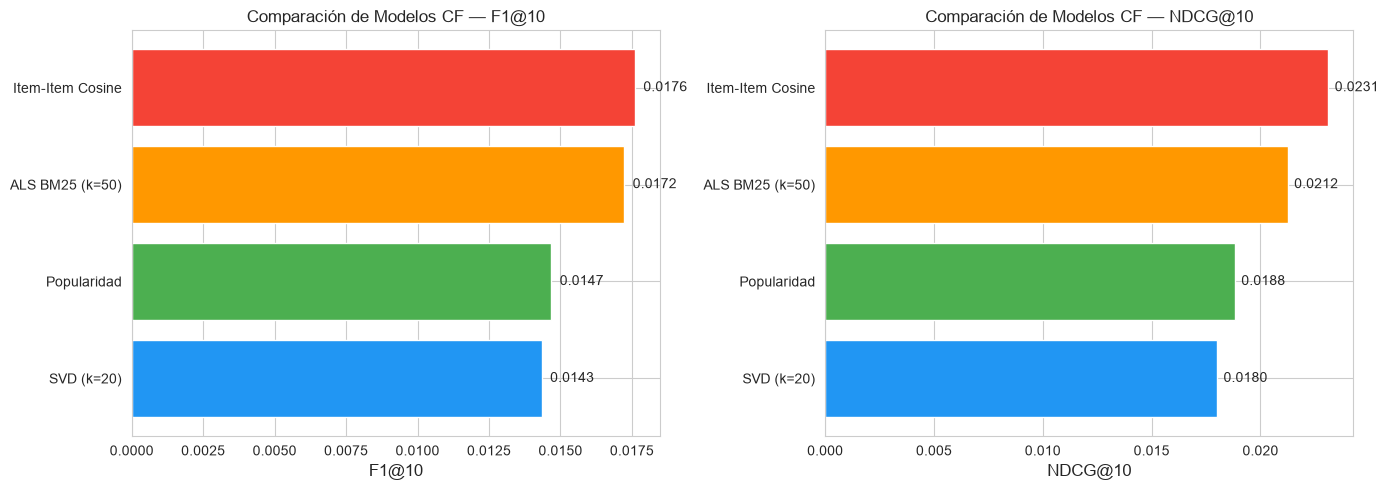

In [13]:
# Construir tabla comparativa con NDCG
comp_rows = []

for k, m in metrics_pop.items():
    comp_rows.append({'Modelo': 'Popularidad', 'K': k,
                      'Precision': m['precision'], 'Recall': m['recall'],
                      'F1': m['f1'], 'NDCG': m['ndcg']})

for k, m in metrics_ii.items():
    comp_rows.append({'Modelo': 'Item-Item Cosine', 'K': k,
                      'Precision': m['precision'], 'Recall': m['recall'],
                      'F1': m['f1'], 'NDCG': m['ndcg']})

for k, m in svd_results[best_svd_k]['metrics'].items():
    comp_rows.append({'Modelo': f'SVD (k={best_svd_k})', 'K': k,
                      'Precision': m['precision'], 'Recall': m['recall'],
                      'F1': m['f1'], 'NDCG': m['ndcg']})

for k, m in als_results[best_als_k]['metrics'].items():
    comp_rows.append({'Modelo': f'ALS BM25 (k={best_als_k})', 'K': k,
                      'Precision': m['precision'], 'Recall': m['recall'],
                      'F1': m['f1'], 'NDCG': m['ndcg']})

df_comparison = pd.DataFrame(comp_rows)

for k_val in [5, 10, 20]:
    print(f"\n=== Métricas @{k_val} ===")
    subset = df_comparison[df_comparison['K'] == k_val][
        ['Modelo', 'Precision', 'Recall', 'F1', 'NDCG']
    ]
    print(subset.to_string(index=False, float_format='{:.4f}'.format))

# Doble barplot: F1@10 y NDCG@10
fig, axes = plt.subplots(1, 2, figsize=(14, 5))

for ax, metric, title in zip(
    axes,
    ['F1', 'NDCG'],
    ['F1@10', 'NDCG@10']
):
    data = df_comparison[df_comparison['K'] == 10][['Modelo', metric]].sort_values(metric, ascending=True)
    colors = ['#2196F3', '#4CAF50', '#FF9800', '#f44336']
    ax.barh(data['Modelo'], data[metric], color=colors[:len(data)])
    ax.set_xlabel(title, fontsize=12)
    ax.set_title(f'Comparación de Modelos CF — {title}', fontsize=12)
    for i, v in enumerate(data[metric]):
        ax.text(v + 0.0003, i, f'{v:.4f}', va='center', fontsize=10)

plt.tight_layout()
plt.show()

## Sección 11: Análisis de Recomendaciones del Mejor Modelo

Determinamos programáticamente cuál fue el mejor modelo según F1@10 y analizamos cualitativamente sus recomendaciones para 5 usuarios de muestra.

Para cada usuario mostramos:
1. **Historial** (top-5 productos más frecuentes en sus compras pasadas).
2. **Carrito real** (ground truth del set de test).
3. **Recomendaciones del mejor modelo** (top-5).

Esto permite evaluar cualitativamente si las recomendaciones tienen sentido semántico (por ejemplo, si un usuario compra mucho orgánico, ¿el modelo recomienda más productos orgánicos?).

In [14]:
# Determinar mejor modelo programáticamente
model_f1s = [
    ('Popularidad', metrics_pop[10]['f1'], recs_popularity),
    ('Item-Item Cosine', metrics_ii[10]['f1'], recs_itemitem),
    (f'SVD (k={best_svd_k})', best_svd_f1, best_svd_recs),
    (f'ALS (k={best_als_k})', best_als_f1, best_als_recs),
]
best_model_name, best_model_f1, best_recs = max(model_f1s, key=lambda x: x[1])
print(f"Mejor modelo: {best_model_name} (F1@10={best_model_f1:.4f})")
print(f"\nComparación F1@10 todos los modelos:")
for name, f1, _ in sorted(model_f1s, key=lambda x: x[1], reverse=True):
    marker = " <-- GANADOR" if name == best_model_name else ""
    print(f"  {name:<25}: {f1:.4f}{marker}")

# Diccionario de nombres de productos
product_names = products.set_index('product_id')['product_name'].to_dict()

def safe_name(pid):
    """Retorna nombre del producto, con fallback al id si no existe."""
    name = product_names.get(pid, str(pid))
    # Fallback ASCII para evitar errores de encoding en Windows
    try:
        return name.encode('utf-8').decode('utf-8')
    except Exception:
        return name.encode('ascii', 'replace').decode('ascii')

# Análisis de 5 usuarios aleatorios
rng = np.random.RandomState(42)
sample_users = rng.choice(list(ground_truth.keys()), size=5, replace=False)

print(f"\n{'='*60}")
print(f"ANÁLISIS CUALITATIVO — MEJOR MODELO: {best_model_name}")
print(f"{'='*60}")

for uid in sample_users:
    # Historial: top-5 productos por frecuencia
    user_hist = df_filtered[df_filtered['user_id'] == uid]['product_id'].value_counts().head(5)
    hist_names = [safe_name(p) for p in user_hist.index]

    # Ground truth
    actual = ground_truth.get(uid, set())
    actual_names = [safe_name(p) for p in list(actual)[:5]]

    # Recomendaciones del mejor modelo
    user_recs = best_recs.get(uid, [])[:5]
    rec_names = [safe_name(p) for p in user_recs]

    # Hits en top-5
    hits_5 = len(set(best_recs.get(uid, [])[:5]) & actual)
    hits_10 = len(set(best_recs.get(uid, [])[:10]) & actual)

    print(f"\n--- Usuario {uid} ---")
    print(f"  Historial (top-5)   : {hist_names}")
    print(f"  Carrito real (top-5): {actual_names}")
    print(f"  Recomendados (top-5): {rec_names}")
    print(f"  Hits: @5={hits_5}, @10={hits_10} de {len(actual)} productos en carrito real")

Mejor modelo: Item-Item Cosine (F1@10=0.0176)

Comparación F1@10 todos los modelos:
  Item-Item Cosine         : 0.0176 <-- GANADOR
  ALS (k=50)               : 0.0172
  Popularidad              : 0.0147
  SVD (k=20)               : 0.0143

ANÁLISIS CUALITATIVO — MEJOR MODELO: Item-Item Cosine

--- Usuario 132366 ---
  Historial (top-5)   : ['Organic Cucumber', 'Organic Broccoli Florets', 'Organic Whole Grassmilk Milk', 'Oven Roasted Chicken Breast', 'Apple Honeycrisp Organic']
  Carrito real (top-5): ['Organic Broccoli Florets', 'Zero Calorie Orange Soda', 'Organic Campari Cocktail Tomatoes', 'Organic Greek Fat Free Plain Yogurt', 'Organic Rainbow Carrots']
  Recomendados (top-5): ['Organic Strawberries', 'Organic Hass Avocado', 'Organic Garlic', 'Organic Zucchini', 'Bag of Organic Bananas']
  Hits: @5=0, @10=0 de 16 productos en carrito real

--- Usuario 3050 ---
  Historial (top-5)   : ['Organic Red Onion', 'Juice Beverage, Cold Pressed, Kale Apple Ginger Romaine Spinach Cucumber Ce

## Sección 12: Persistencia de Artefactos

Guardamos todos los artefactos generados en `data/processed/` y `models/`:

- **cf_metrics.csv**: tabla completa de métricas de todos los modelos y valores de K.
- **cf_recommendations.parquet**: recomendaciones del mejor modelo (user_id, rank, product_id).
- **cf_item_similarity.npz**: matriz sparse de similitud item-item (formato scipy NPZ).
- **models/cf_best_model.pkl**: el mejor modelo serializado con joblib para uso en producción.

Estos artefactos permiten consumir las recomendaciones directamente sin re-entrenar los modelos.

In [15]:
# ── 1. Guardar métricas ────────────────────────────────────────────────────────
metrics_path = os.path.join(PROCESSED_DIR, 'cf_metrics.csv')
df_comparison.to_csv(metrics_path, index=False)

# ── 2. Guardar recomendaciones del mejor modelo ────────────────────────────────
rec_rows = []
for uid, prods in best_recs.items():
    for rank, pid in enumerate(prods, 1):
        rec_rows.append({'user_id': uid, 'rank': rank, 'product_id': pid})
df_recs = pd.DataFrame(rec_rows)
recs_path = os.path.join(PROCESSED_DIR, 'cf_recommendations.parquet')
df_recs.to_parquet(recs_path, index=False)

# ── 3. Guardar similitud item-item (sparse) ────────────────────────────────────
sim_path = os.path.join(PROCESSED_DIR, 'cf_item_similarity.npz')
save_npz(sim_path, item_similarity)

# ── 4. Guardar mejor modelo con joblib ────────────────────────────────────────
# Guardamos el modelo junto con los mappings necesarios para inferencia
model_artifact = {
    'model_name': best_model_name,
    'model_f1_10': best_model_f1,
    'user_to_idx': user_to_idx,
    'product_to_idx': product_to_idx,
    'idx_to_product': idx_to_product,
}
if 'ALS' in best_model_name:
    model_artifact['als_model'] = best_als_model
elif 'SVD' in best_model_name:
    model_artifact['svd_model'] = best_svd_model
    model_artifact['user_factors'] = user_factors  # última iteración del loop
    model_artifact['item_factors'] = item_factors

model_path = os.path.join(MODELS_DIR, 'cf_best_model.pkl')
joblib.dump(model_artifact, model_path)

# ── 5. Reporte de artefactos ──────────────────────────────────────────────────
print("Artefactos guardados:")
artifacts = [
    ('cf_metrics.csv', metrics_path),
    ('cf_recommendations.parquet', recs_path),
    ('cf_item_similarity.npz', sim_path),
    ('models/cf_best_model.pkl', model_path),
]
for label, path in artifacts:
    if os.path.exists(path):
        size = os.path.getsize(path) / 1024
        unit = 'KB'
        if size > 1024:
            size /= 1024
            unit = 'MB'
        print(f"  [OK] {label:<35} {size:>8.1f} {unit}")
    else:
        print(f"  [!!] {label} — NO encontrado")

print(f"\nTotal recomendaciones guardadas: {len(df_recs):,} filas ({df_recs['user_id'].nunique():,} usuarios)")
print(f"Mejor modelo final: {best_model_name} (F1@10={best_model_f1:.4f})")

Artefactos guardados:
  [OK] cf_metrics.csv                           1.2 KB
  [OK] cf_recommendations.parquet               3.8 MB
  [OK] cf_item_similarity.npz                   7.9 MB
  [OK] models/cf_best_model.pkl                 4.4 MB

Total recomendaciones guardadas: 2,066,500 filas (103,325 usuarios)
Mejor modelo final: Item-Item Cosine (F1@10=0.0176)
